#Restaurant Data Analysis whith Pthon
-> Data Colection

-> Data Cleaning

-> Data Visualisation

-> Insights

-> Report

In [ ]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Data Collection
-> Import data in CSV , excel , json etc. file

In [ ]:
#import data
data = pd.read_csv('/content/restaurant.csv')
data.head(10)

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4
5,5,25.29,4.71,Male,No,Sun,Dinner,4
6,6,8.77,2.00,Male,No,Sun,Dinner,2
7,7,26.88,3.12,Male,No,Sun,Dinner,4
8,8,15.04,1.96,Male,No,Sun,Dinner,2
9,9,14.78,3.23,Male,No,Sun,Dinner,2


##This dataset contains restaurant data including ratings, location, and pricing.

## 1. Data Cleaning

-> Find Missing Values

-> Handeling Mising Values

-> Find duplicates & delete

-> Find Outliers and Remove

In [ ]:
data.head() #get first 5 rows

,Unnamed: 0,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
#Find Missing values
data.isnull().sum()
#our data don't have any null values

,0
Unnamed: 0,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


In [ ]:
#check duplicates
data.duplicated().sum()
#there have no duplicates

np.int64(0)

In [ ]:
#give name to unnamed column
data.rename(columns={'Unnamed: 0':'ID'},inplace=True)

In [ ]:
data.head()

,ID,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4


## Analysis on data

In [ ]:
#check smokers gender
smokers = data[data['smoker']=='Yes']['sex'].value_counts()
smokers

,count
sex,
Male,60
Female,33


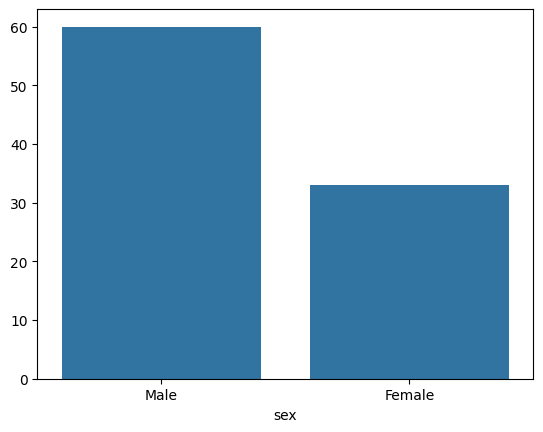

In [ ]:
# plot bar chart
sns.barplot(x=smokers.index,y=smokers.values)
plt.show()

##Insight_1 : mostly male smokers are come to the restaurant

In [ ]:
# day wise count of gender
day_wise = data.groupby(['sex','day'])['total_bill'].count().unstack()
day_wise

day,Fri,Sat,Sun,Thur
sex,,,,
Female,9,28,18,32
Male,10,59,58,30


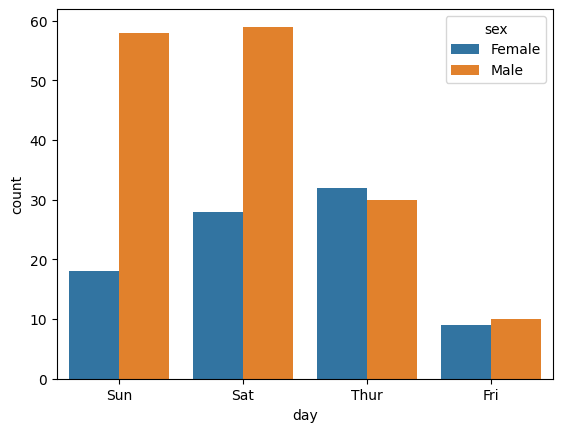

In [ ]:
# plot a bar chart
sns.countplot(data=data,x='day',hue='sex')
plt.show()

##Insight_2 : mostly male are come to saturday and sunday , while mostly  female are on thursday and saturday

In [ ]:
#check who spend more by gender
gender_spend = data.groupby('sex')['total_bill'].sum()
gender_spend


,total_bill
sex,
Female,1570.95
Male,3256.82


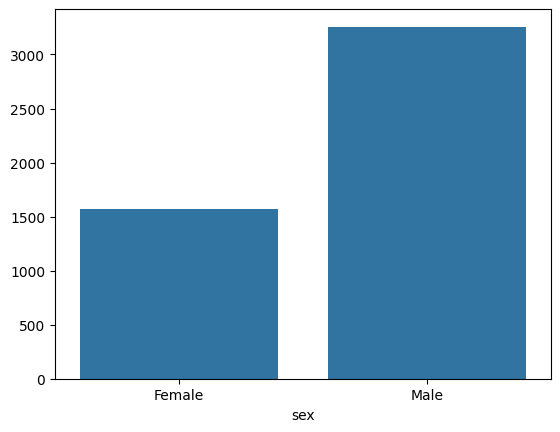

In [ ]:
#plot bar chart
sns.barplot(x=gender_spend.index,y=gender_spend.values)
plt.show()


In [ ]:
#check smokers spend
smoker_spend = data.groupby(['smoker','sex'])['total_bill'].sum()
smoker_spend

smoker  sex   
No      Female     977.68
        Male      1919.75
Yes     Female     593.27
        Male      1337.07
Name: total_bill, dtype: float64

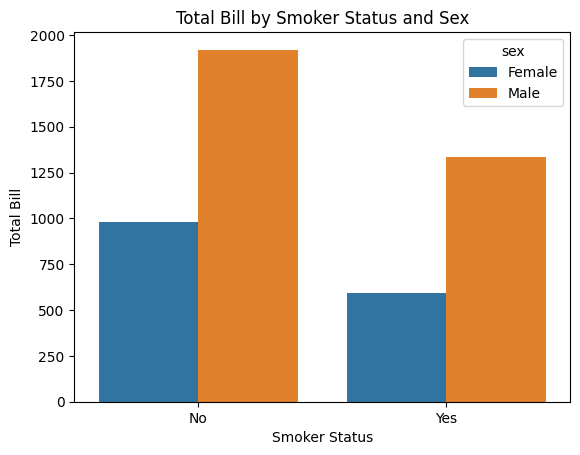

In [ ]:
smoker_spend_df = smoker_spend.reset_index()
sns.barplot(data=smoker_spend_df, x='smoker', y='total_bill', hue='sex')
plt.title('Total Bill by Smoker Status and Sex')
plt.xlabel('Smoker Status')
plt.ylabel('Total Bill')
plt.show()

## Insight_3 : From above two graphs we can see the mostly non-smoker male spend more

In [ ]:
data.head()

,ID,total_bill,tip,sex,smoker,day,time,size
0,0,16.99,1.01,Female,No,Sun,Dinner,2
1,1,10.34,1.66,Male,No,Sun,Dinner,3
2,2,21.01,3.50,Male,No,Sun,Dinner,3
3,3,23.68,3.31,Male,No,Sun,Dinner,2
4,4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
# check time by gender
time_by_gender = data.groupby(['sex','time'])['total_bill'].count().unstack()
time_by_gender

time,Dinner,Lunch
sex,,
Female,52,35
Male,124,33


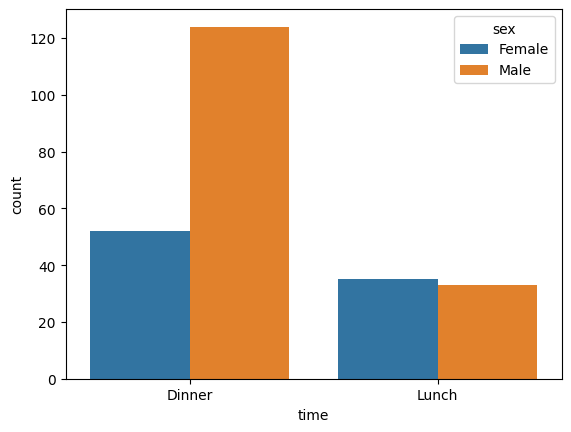

In [ ]:
#plot graph
sns.countplot(data=data,x='time',hue='sex')
plt.show()

In [ ]:
# which gender spend more on which time
time_spend = data.groupby(['sex','time'])['total_bill'].sum()
time_spend

sex     time  
Female  Dinner     999.08
        Lunch      571.87
Male    Dinner    2661.22
        Lunch      595.60
Name: total_bill, dtype: float64

<Axes: xlabel='time', ylabel='total_bill'>

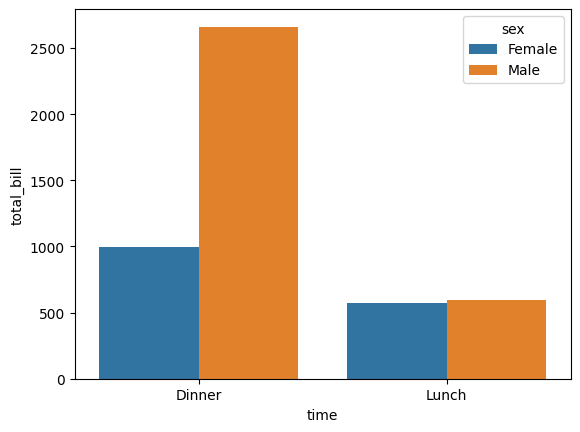

In [ ]:
# plot graph
time_spend_df = time_spend.reset_index()
sns.barplot(data=time_spend_df, x='time', y='total_bill', hue='sex')

## Insight_4 : From Above Two Graph we can see mostly people , come at dinner time and also spend more at that time

#Key Insights from the Analysis
-> Customer traffic is highest during dinner time :
indicating that restaurants experience peak demand in the evening.

-> Non-smoker male customers tend to spend more on average compared to female customers, suggesting a higher spending pattern in this segment.

-> Weekend footfall is dominated by male customers, especially on Saturday and Sunday, showing a strong weekend dining trend.

-> Female customer visits are relatively higher on Thursday and Saturday, indicating a mixed pattern of weekday and weekend engagement.